<a href="https://colab.research.google.com/github/Ullas2534/Projects/blob/main/Stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/stocks.csv")

In [ ]:
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


In [ ]:
df.describe()


,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


In [ ]:
df.columns

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')

In [ ]:
print(df.isnull().sum())

# Drop rows with missing values if necessary
df.dropna(inplace=True)

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])
# Sort by date
df.sort_values(by='Date', inplace=True)


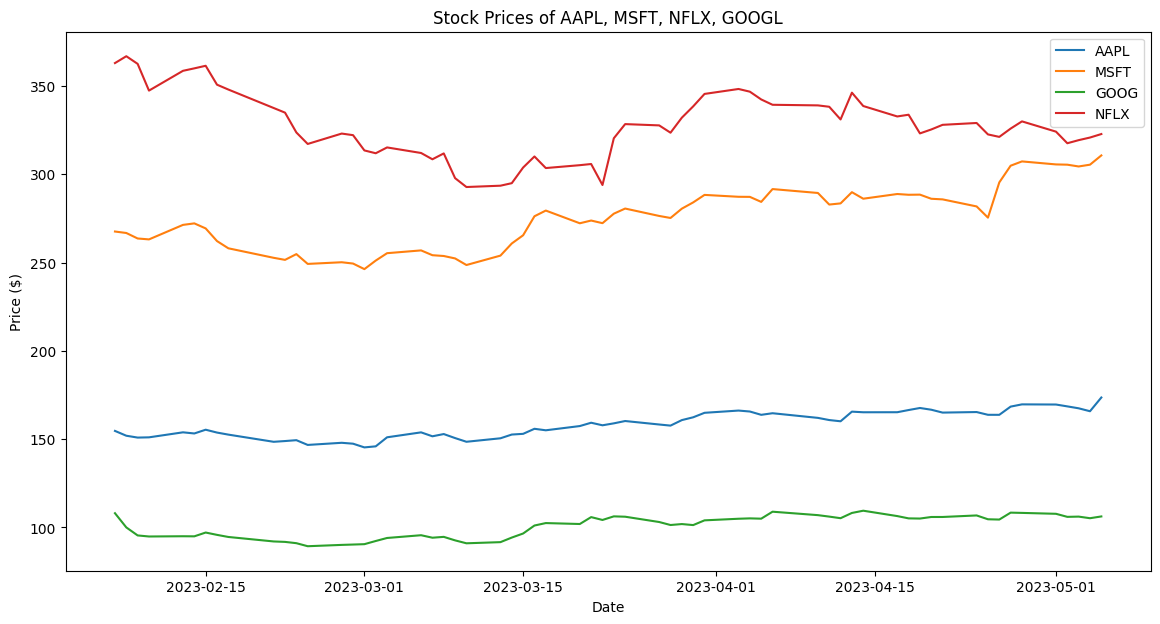

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for each ticker
tickers = df['Ticker'].unique()

plt.figure(figsize=(14, 7))
for ticker in tickers:
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Close'], label=ticker)

plt.title('Stock Prices of AAPL, MSFT, NFLX, GOOGL')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


In [ ]:
# Calculate 20-day moving average for each ticker
for ticker in tickers:
    df.loc[df['Ticker'] == ticker, 'MA_20'] = df[df['Ticker'] == ticker]['Close'].rolling(window=20).mean()


In [ ]:
# Calculate daily returns and volatility
for ticker in tickers:
    df.loc[df['Ticker'] == ticker, 'Daily Return'] = df[df['Ticker'] == ticker]['Close'].pct_change()

# Calculate annualized volatility
volatility = df.groupby('Ticker')['Daily Return'].std() * (252**0.5)  # Annualized
print(volatility)


Ticker
AAPL    0.224660
GOOG    0.328764
MSFT    0.283849
NFLX    0.356880
Name: Daily Return, dtype: float64


In [ ]:
# Example: Adding volatility as a feature
for ticker in tickers:
    df.loc[df['Ticker'] == ticker, 'Volatility'] = df[df['Ticker'] == ticker]['Daily Return'].rolling(window=20).std()


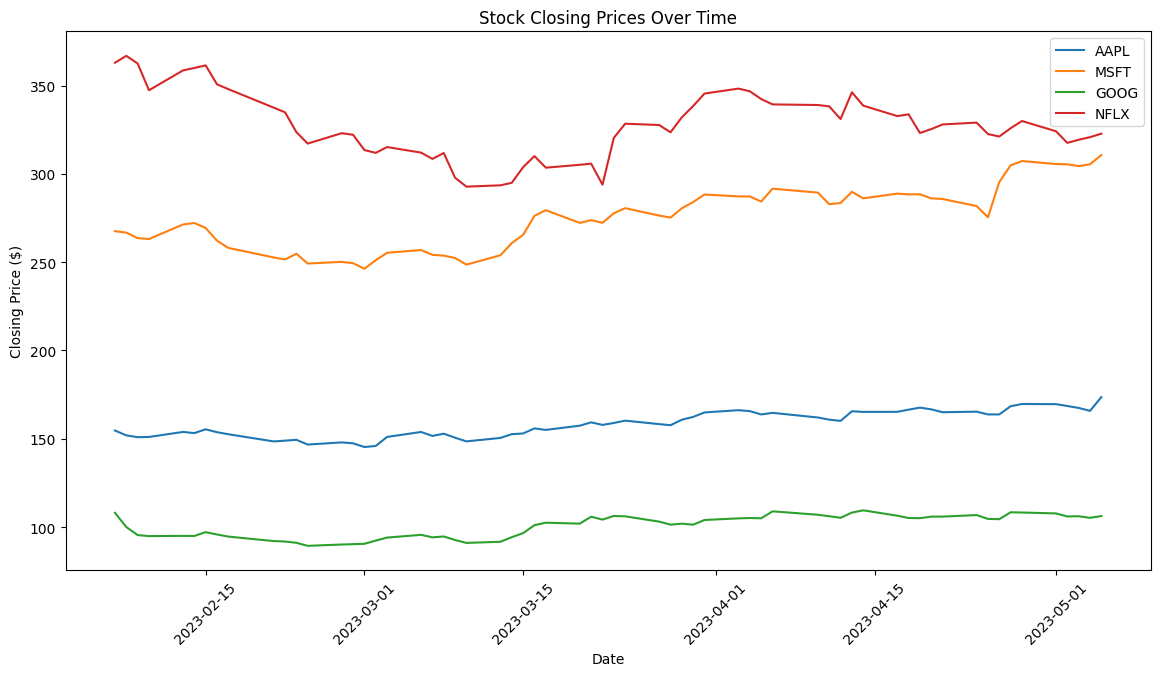

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
for ticker in df['Ticker'].unique():
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Close'], label=ticker)

plt.title('Stock Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.show()


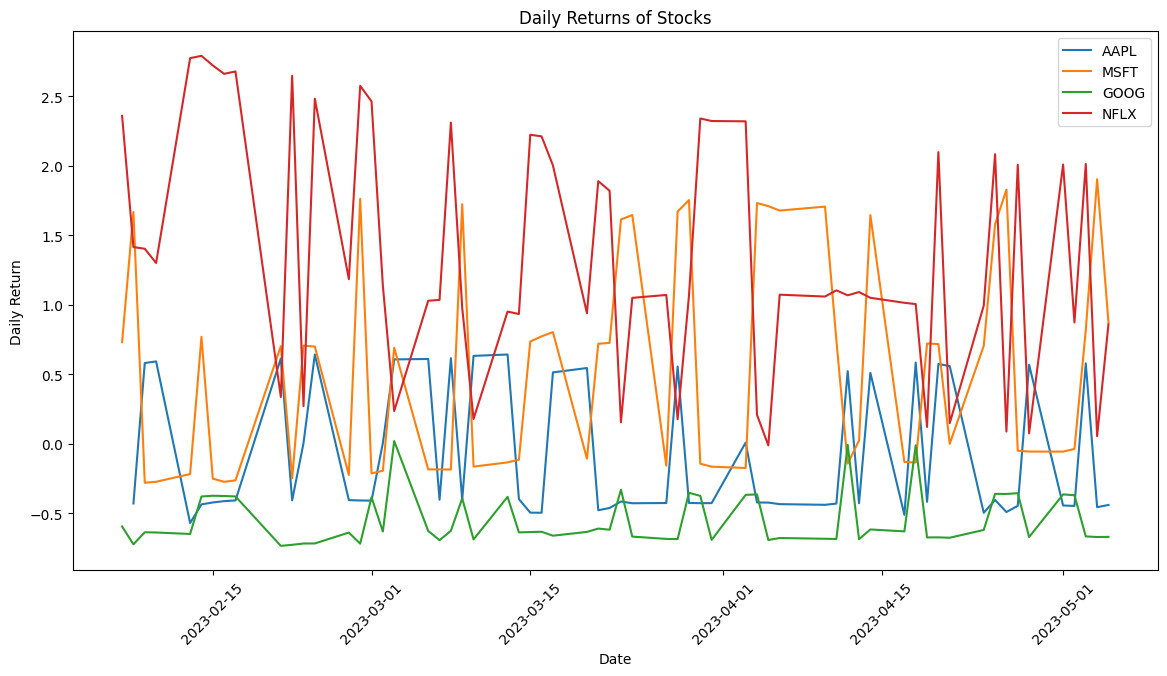

In [ ]:
# Calculate daily returns
df['Daily Return'] = df['Close'].pct_change()
plt.figure(figsize=(14, 7))
for ticker in df['Ticker'].unique():
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Daily Return'], label=ticker)

plt.title('Daily Returns of Stocks')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.xticks(rotation=45)
plt.show()


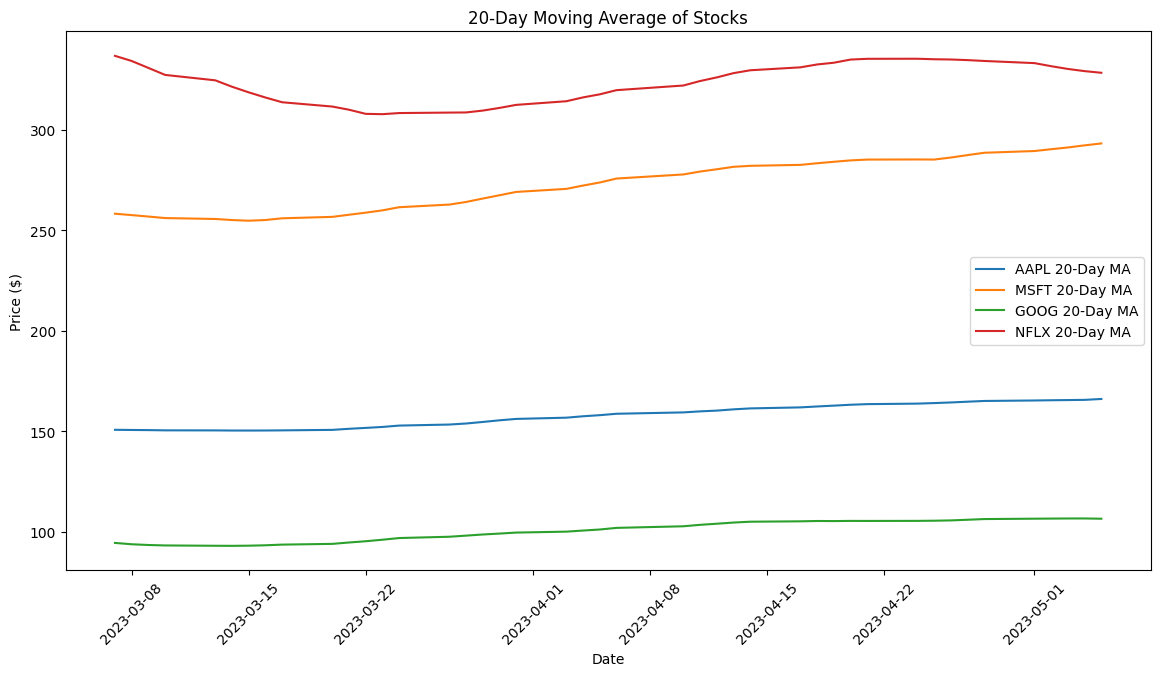

In [ ]:
# Calculate moving averages
for ticker in df['Ticker'].unique():
    df.loc[df['Ticker'] == ticker, 'MA_20'] = df[df['Ticker'] == ticker]['Close'].rolling(window=20).mean()

# Plot moving averages
plt.figure(figsize=(14, 7))
for ticker in df['Ticker'].unique():
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['MA_20'], label=f'{ticker} 20-Day MA')

plt.title('20-Day Moving Average of Stocks')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.show()


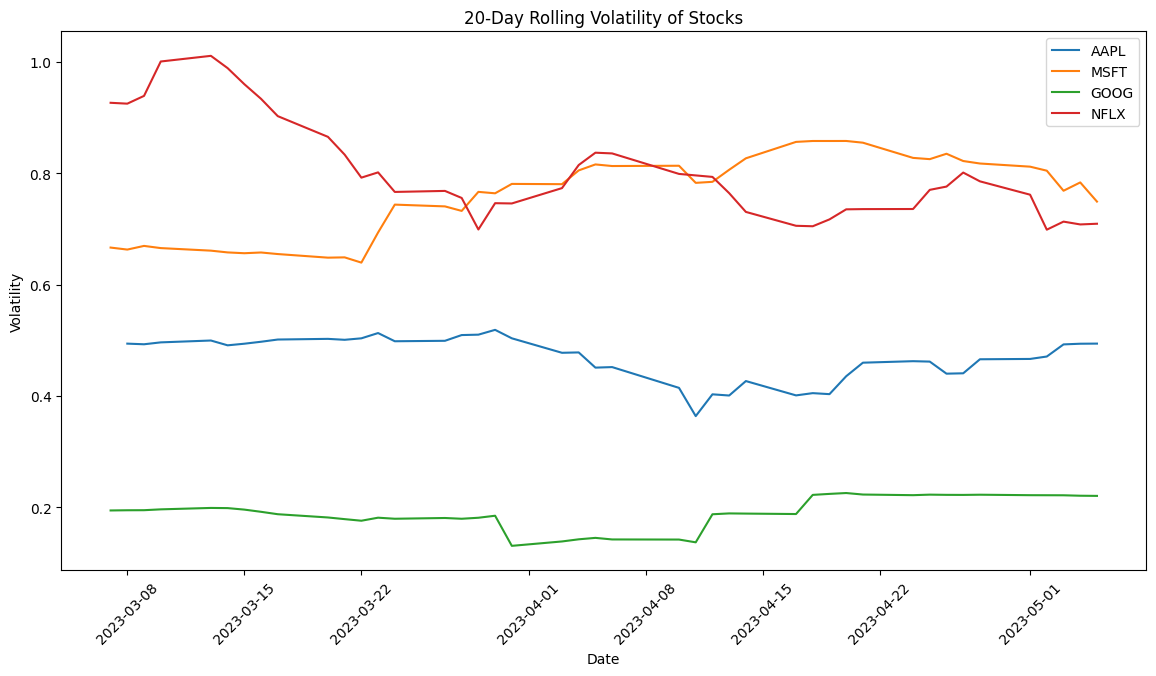

In [ ]:
# Calculate rolling volatility
for ticker in df['Ticker'].unique():
    df.loc[df['Ticker'] == ticker, 'Volatility'] = df[df['Ticker'] == ticker]['Daily Return'].rolling(window=20).std()

# Plot volatility
plt.figure(figsize=(14, 7))
for ticker in df['Ticker'].unique():
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Volatility'], label=ticker)

plt.title('20-Day Rolling Volatility of Stocks')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.xticks(rotation=45)
plt.show()


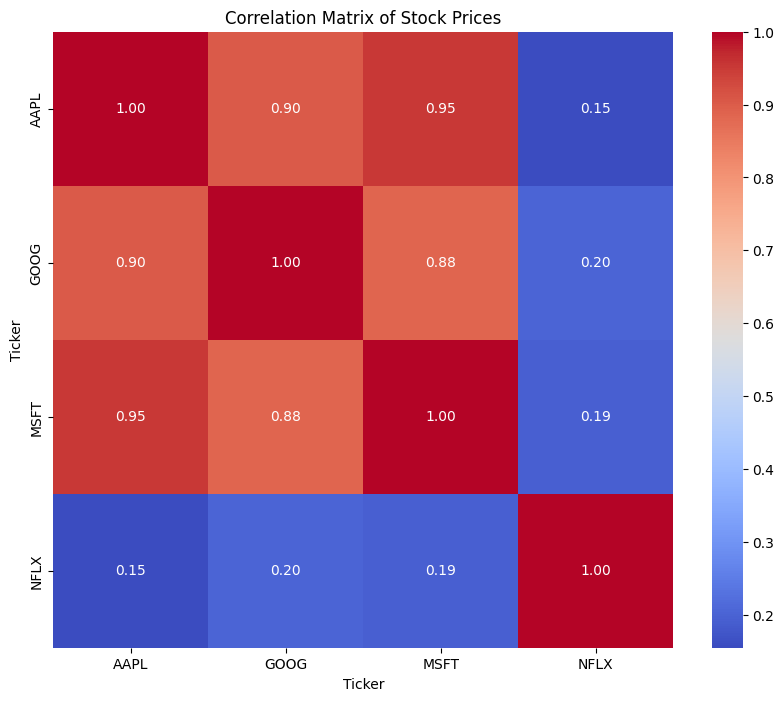

In [ ]:
# Pivot data for correlation analysis
pivot_df = df.pivot(index='Date', columns='Ticker', values='Close')
correlation_matrix = pivot_df.corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Stock Prices')
plt.show()


In [ ]:
# Summary statistics for daily returns
daily_return_summary = df.groupby('Ticker')['Daily Return'].describe()
print(daily_return_summary)


        count      mean       std       min       25%       50%       75%  \
Ticker                                                                      
AAPL     61.0 -0.100196  0.473152 -0.570935 -0.435322 -0.409957  0.544197   
GOOG     62.0 -0.552381  0.184434 -0.735458 -0.678576 -0.635743 -0.380011   
MSFT     62.0  0.539927  0.769637 -0.281356 -0.163487  0.694526  0.859781   
NFLX     62.0  1.362969  0.867781 -0.012689  0.934310  1.081571  2.183040   

             max  
Ticker            
AAPL    0.641970  
GOOG    0.018525  
MSFT    1.902861  
NFLX    2.791048  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Prepare features and target variable
features = df[['Open', 'High', 'Low', 'Volume', 'MA_20', 'Volatility']]  # Example features
target = df['Close']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean') # Create an imputer instance
X_train = imputer.fit_transform(X_train) # Fit and transform on training data
X_test = imputer.transform(X_test) # Transform the test data

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}, R^2: {r2}')

MSE: 2.9692087035282566, R^2: 0.9996554162178133


In [ ]:
import joblib

# Save the model (if you haven't already)
joblib.dump(model, 'stock_model.pkl')

# Load the model for predictions
loaded_model = joblib.load('stock_model.pkl')

# Instead of pd.read_csv, load your new data using a method appropriate for its format
# For example, if your new data is in a CSV file called 'new_stock_data.csv':
# new_data = pd.read_csv("/content/new_stock_data.csv")  # Replace with the actual path to your new data file
# Assuming your new data is in a pandas DataFrame called 'new_df':
new_data = pd.DataFrame({ # Replace with your actual new data
    'Open': [150, 152],
    'High': [153, 155],
    'Low': [149, 151],
    'Volume': [1000000, 1200000],
    'MA_20': [151, 153],
    'Volatility': [0.02, 0.03]
})
# Make predictions
predictions = loaded_model.predict(new_data)
print(predictions) # Print the predictions

[151.46563794 153.84048665]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
import joblib

# Save the model (if you haven't already)
joblib.dump(model, 'stock_model.pkl')

# Load the model for predictions
loaded_model = joblib.load('stock_model.pkl')
print(loaded_model)

LinearRegression()
